**Лабораторная работа 5**

**Изучение нейронной сети Хопфилда. Информационная емкость ассоциативной памяти.**

*Импорт необходимых библиотек*

In [32]:
import warnings

import matplotlib.pyplot as plt
import matplotlib.text as mtext
import numpy as np
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.figure import Figure
from skimage.transform import resize

warnings.filterwarnings('ignore')

*Анализ поведения системы с обратной связью*

In [33]:
def feedback_system(w, n_steps=30, x0=1):
    y = np.zeros(n_steps)
    for n in range(n_steps):
        s = 0
        for l in range(n + 1):
            s += (w ** (l + 1)) * x0
        y[n] = s
    return y

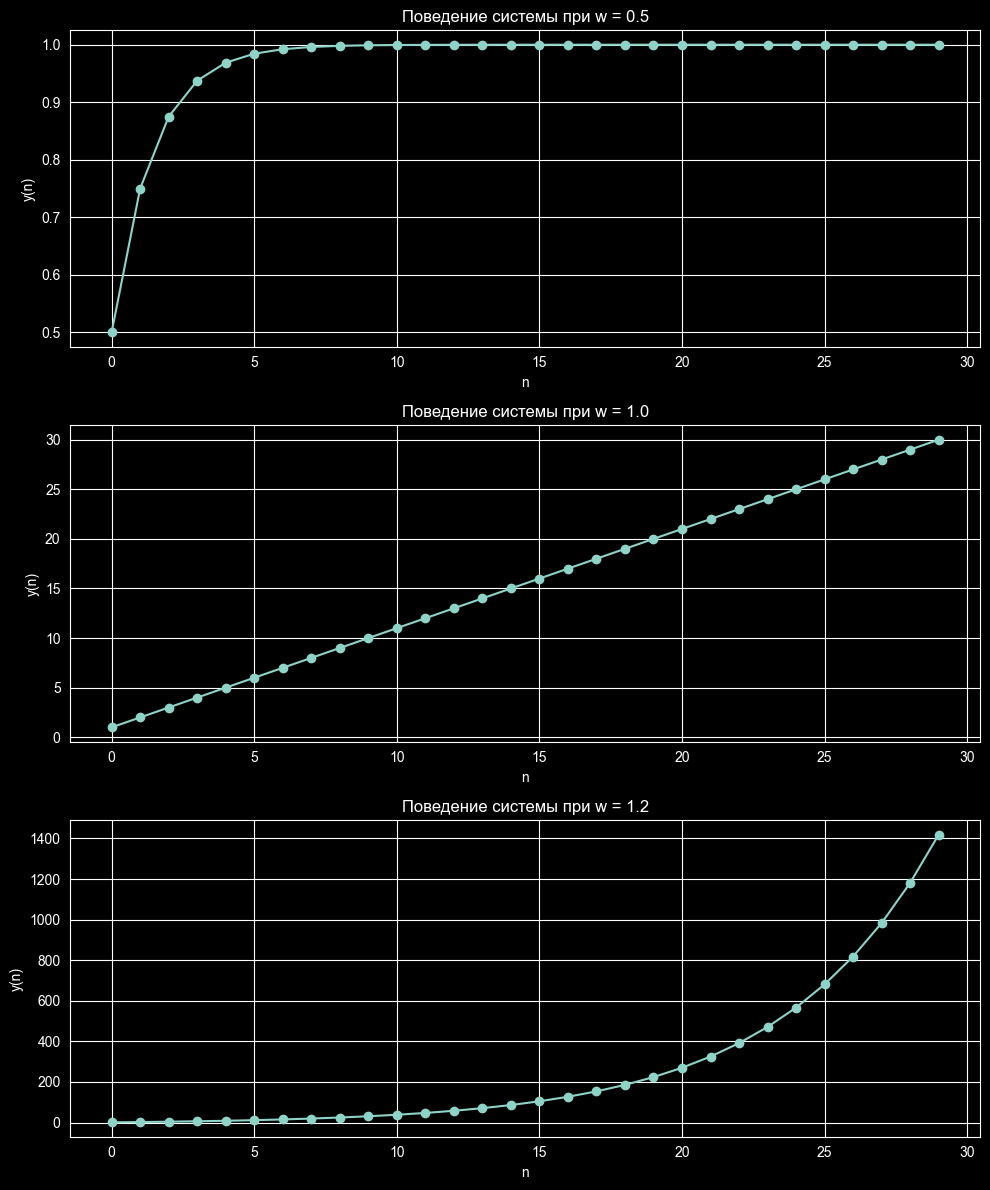

In [34]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
for i, w in enumerate([0.5, 1.0, 1.2]):
    y = feedback_system(w)
    axes[i].plot(y, marker='o')
    axes[i].set_title(f'Поведение системы при w = {w}')
    axes[i].set_xlabel('n')
    axes[i].set_ylabel('y(n)')
    axes[i].grid(True)
plt.tight_layout()
plt.show()

*Набор весовых коэффициентов сети Хопфилда*

In [35]:
x = np.array([1, -1, 1, -1])
W = np.outer(x, x)
np.fill_diagonal(W, 0)
print("Матрица весов:")
print(W)

print("\nПроверка устойчивости:\n")
stable = True
for i in range(len(x)):
    net = np.dot(W[i], x)
    if net > 0:
        new_state = 1
    elif net < 0:
        new_state = -1
    else:
        new_state = x[i]
    print(f"Нейрон {i + 1}: net = {net:2.0f}, новое состояние = {new_state}")
    if new_state != x[i]:
        stable = False
if stable:
    print("\nОбраз является устойчивым состоянием сети.")
else:
    print("\nОбраз НЕ является устойчивым.")

Матрица весов:
[[ 0 -1  1 -1]
 [-1  0 -1  1]
 [ 1 -1  0 -1]
 [-1  1 -1  0]]

Проверка устойчивости:

Нейрон 1: net =  3, новое состояние = 1
Нейрон 2: net = -3, новое состояние = -1
Нейрон 3: net =  3, новое состояние = 1
Нейрон 4: net = -3, новое состояние = -1

Образ является устойчивым состоянием сети.


*Одновременное запоминание нескольких образцов*

In [36]:
def train_hopfield_network(patterns):
    patterns = np.array(patterns)
    N = patterns.shape[1]
    M = patterns.shape[0]
    M_max = N / (2 * np.log(N))
    print(f"Количество нейронов N = {N}")
    print(f"Количество образцов M = {M}")
    print(f"Теоретическая ёмкость M_max = {M_max:.2f}")
    if M > M_max:
        print(f"M ({M}) > M_max ({M_max:.2f}). Восстановление может быть нестабильным.")
    W = np.zeros((N, N))
    for p in patterns:
        W += np.outer(p, p)
    np.fill_diagonal(W, 0)
    W /= N
    return W


def hopfield_recover(W, pattern, iterations=10):
    state = pattern.copy()
    N = len(state)
    for _ in range(iterations):
        for i in np.random.permutation(N):
            net = np.dot(W[i], state)
            state[i] = 1 if net >= 0 else -1
    return state

In [37]:
x1 = np.array([-1, 1, -1])  # один образец
W_correct = train_hopfield_network([x1])
print("Матрица W:\n", W_correct)
recovered = hopfield_recover(W_correct, x1)
print("Восстановление:", recovered)
print("Успешно:", np.array_equal(recovered, x1))

Количество нейронов N = 3
Количество образцов M = 1
Теоретическая ёмкость M_max = 1.37
Матрица W:
 [[ 0.         -0.33333333  0.33333333]
 [-0.33333333  0.         -0.33333333]
 [ 0.33333333 -0.33333333  0.        ]]
Восстановление: [-1  1 -1]
Успешно: True


*Число образцов фундаментальной памяти*

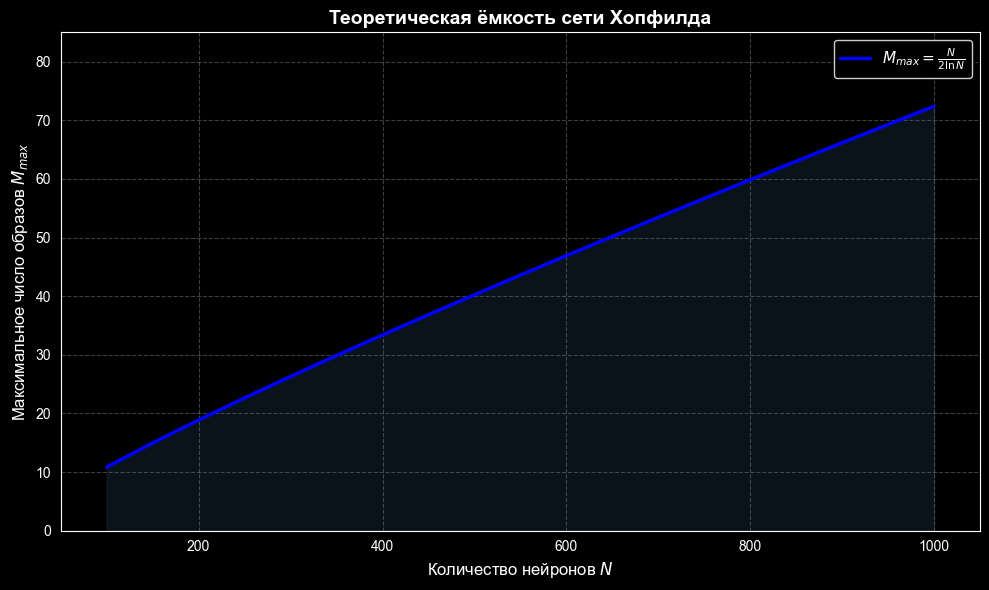

In [38]:
def plot_hopfield_capacity():
    N_values = np.arange(100, 1050, 50)
    M_theoretical = N_values / (2 * np.log(N_values))
    plt.figure(figsize=(10, 6))
    plt.plot(N_values, M_theoretical, 'b-', linewidth=2.5, label=r'$M_{max} = \frac{N}{2 \ln N}$')
    plt.fill_between(N_values, 0, M_theoretical, alpha=0.15, color='steelblue')
    plt.xlabel('Количество нейронов $N$', fontsize=12)
    plt.ylabel('Максимальное число образов $M_{max}$', fontsize=12)
    plt.title('Теоретическая ёмкость сети Хопфилда', fontsize=14, fontweight='semibold')
    plt.grid(True, alpha=0.25, linestyle='--')
    plt.legend(loc='best', fontsize=11, frameon=True, fancybox=True, shadow=True)
    plt.xlim(50, 1050)
    plt.ylim(0, 85)
    plt.tight_layout()
    plt.show()


plot_hopfield_capacity()

*Извлечение зашумлённых образов из фундаментальной памяти*

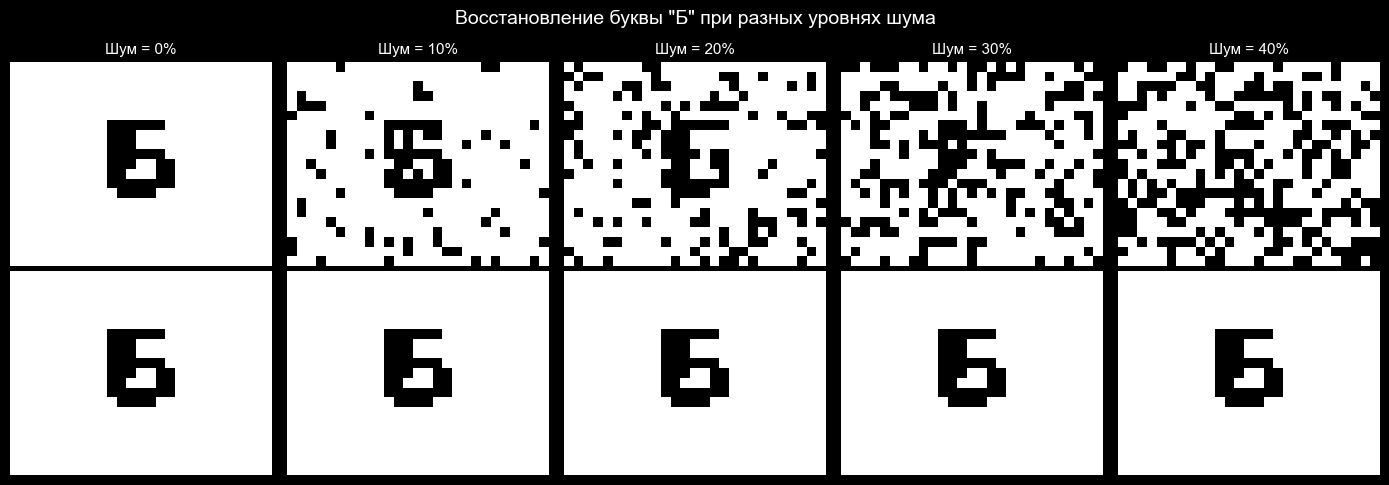

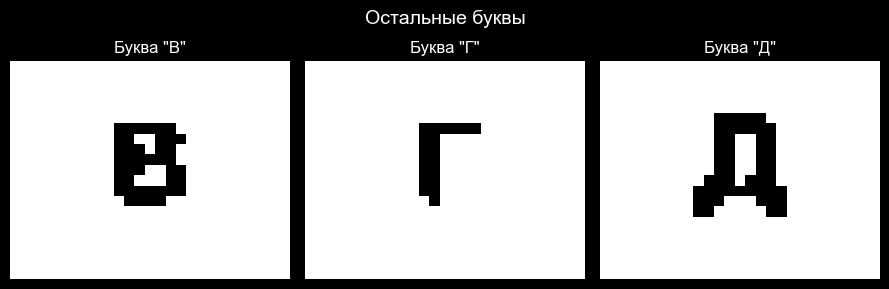

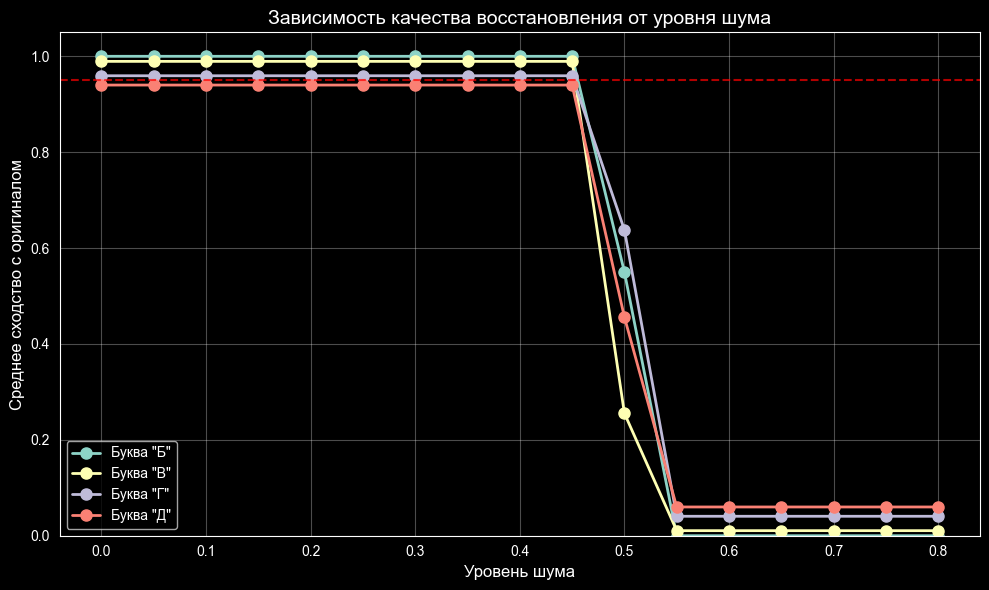

In [43]:
def generate_letter(symbol, size=(21, 27)):
    fig = Figure(figsize=(size[1] / 10, size[0] / 10), dpi=100)
    canvas = FigureCanvasAgg(fig)
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    text = mtext.Text(0.5, 0.5, symbol, fontsize=80, fontweight='bold',
                      ha='center', va='center', family='DejaVu Sans')
    ax.add_artist(text)
    canvas.draw()
    img = np.asarray(canvas.buffer_rgba())
    gray = np.dot(img[..., :3], [0.2989, 0.5870, 0.1140])
    bw = gray < 200
    rows = np.where(bw.sum(axis=1) > 0)[0]
    cols = np.where(bw.sum(axis=0) > 0)[0]
    bw_crop = bw[rows.min():rows.max() + 1, cols.min():cols.max() + 1]
    bw_resized = (resize(bw_crop.astype(float), size) > 0.5)
    return np.where(bw_resized, 1, -1).flatten()


class HopfieldNetwork:
    def __init__(self):
        self.W = None
        self.N = None

    def train(self, patterns):
        patterns = np.array(patterns)
        self.N = patterns.shape[1]
        self.W = np.zeros((self.N, self.N))
        for p in patterns:
            self.W += np.outer(p, p)
        np.fill_diagonal(self.W, 0)
        self.W /= self.N
        return self.W

    def recover(self, pattern, iterations=10):
        state = pattern.copy()
        for _ in range(iterations):
            for i in np.random.permutation(self.N):
                net = np.dot(self.W[i], state)
                state[i] = 1 if net > 0 else (-1 if net < 0 else state[i])
        return state

    def add_noise(self, pattern, noise_level):
        noisy = pattern.copy()
        n_flips = int(noise_level * self.N)
        flip_idx = np.random.choice(self.N, n_flips, replace=False)
        noisy[flip_idx] *= -1
        return noisy

    def similarity(self, pattern1, pattern2):
        return np.sum(pattern1 == pattern2) / self.N


word = ['Б', 'В', 'Г', 'Д']
size = (21, 27)
h, w = size

patterns = {}
for letter in word:
    patterns[letter] = generate_letter(letter, size)

hopfield = HopfieldNetwork()
pattern_list = list(patterns.values())
hopfield.train(pattern_list)

test_letter = word[0]
original_M = patterns[test_letter]
noise_levels = [0, 0.1, 0.2, 0.3, 0.4]

fig, axes = plt.subplots(2, len(noise_levels), figsize=(14, 5))

for idx, noise in enumerate(noise_levels):
    noisy = hopfield.add_noise(original_M, noise)
    recovered = hopfield.recover(noisy)
    sim = hopfield.similarity(recovered, original_M)
    axes[0, idx].imshow(noisy.reshape(h, w), cmap='gray')
    axes[0, idx].set_title(f'Шум = {noise:.0%}', fontsize=11)
    axes[0, idx].axis('off')
    axes[1, idx].imshow(recovered.reshape(h, w), cmap='gray')
    status = f"{sim:.1%}"
    color = 'green' if sim > 0.5 else 'red'
    axes[1, idx].axis('off')

axes[0, 0].set_ylabel('Зашумленный', fontsize=12)
axes[1, 0].set_ylabel('Восстановленный', fontsize=12)
plt.suptitle(f'Восстановление буквы "{test_letter}" при разных уровнях шума', fontsize=14)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
letters_to_show = word[1:]
for idx, letter in enumerate(letters_to_show):
    axes[idx].imshow(patterns[letter].reshape(h, w), cmap='gray')
    axes[idx].set_title(f'Буква "{letter}"', fontsize=12)
    axes[idx].axis('off')
plt.suptitle('Остальные буквы', fontsize=14)
plt.tight_layout()
plt.show()

max_noise = 0.0
threshold_similarity = 0.95
test_noises = np.arange(0, 0.51, 0.01)

if max_noise < 0.5:
    check_noise = min(max_noise + 0.05, 0.5)
    failures = []
    for letter, original in patterns.items():
        sim_sum = 0
        for test in range(10):
            noisy = hopfield.add_noise(original, check_noise)
            recovered = hopfield.recover(noisy)
            sim_sum += hopfield.similarity(recovered, original)
        failures.append((letter, sim_sum / 10))

plt.figure(figsize=(10, 6))
noise_range = np.arange(0, 0.85, 0.05)
results = {letter: [] for letter in patterns.keys()}

for noise in noise_range:
    for letter, original in patterns.items():
        similarities = []
        for test in range(20):
            noisy = hopfield.add_noise(original, noise)
            recovered = hopfield.recover(noisy)
            similarities.append(hopfield.similarity(recovered, original))
        results[letter].append(np.mean(similarities))

for letter, sims in results.items():
    plt.plot(noise_range, sims, 'o-', label=f'Буква "{letter}"', linewidth=2, markersize=8)

plt.axhline(y=threshold_similarity, color='red', linestyle='--', alpha=0.7)
plt.xlabel('Уровень шума', fontsize=12)
plt.ylabel('Среднее сходство с оригиналом', fontsize=12)
plt.title('Зависимость качества восстановления от уровня шума', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()